<a href="https://colab.research.google.com/github/Ishmeet482/User-Success-Prediction/blob/main/User_Success_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# User Success Prediction — Executive Summary

---

##  Project Overview

This analysis answers a single critical question: **what separates power users from one-time visitors on the AI platform?** Using a full behavioral event log, I engineered predictive features, trained a Random Forest classifier, and segmented users into meaningful cohorts — all to surface actionable growth levers for the AI tool.

---

## 📊 Dataset Statistics

| Metric | Value |
|---|---|
| **Total Users Analysed** | 4,771 |
| **Total Raw Events** | ~409,300 |
| **Unique Event Types** | 141 |
| **Engineered Features** | 148 (142 base + 6 behavioral) |
| **Success Rate (top-20% by activity)** | ~19.7% |
| **Date Range** | Sep 2025 – Dec 2025 |
| **Success Threshold** | ≥ 16 total events |

---

## 🏆 Top 5 Success Predictors

Ranked by Random Forest feature importance (trained on 4,771 users × 148 features):

| Rank | Feature | Importance | Type |
|---|---|---|---|
| 🥇 1 | `diversity_score` — breadth of unique action types | **17.98%** | ★ Engineered |
| 🥈 2 | `avg_events_per_session` — depth per visit | **16.97%** | ★ Engineered |
| 🥉 3 | `agent_tool_call_get_canvas_summary_tool` — AI agent usage | **5.82%** | Raw Event |
| 4 | `agent_tool_call_get_block_tool` — detailed block inspection | **5.58%** | Raw Event |
| 5 | `agent_tool_call_finish_ticket_tool` — task completion via AI | **5.35%** | Raw Event |

> **Key Insight:** The two most powerful predictors are *engineered* behavioral features — not raw event counts. Users who explore broadly (high diversity) and engage deeply per session are the strongest predictors of success, outperforming all 141 raw event signals. AI agent adoption is the dominant raw-event predictor.

---

##  User Segment Breakdown

K-Means clustering (k=5, silhouette score = **0.688**) identified five distinct user personas:

| Segment | Size | % of Users | Profile |
|---|---|---|---|
| 👀 **One-Time Visitors** (×3 clusters) | 4,452 | **93.3%** | Single session, minimal engagement, no AI usage |
| 🔍 **Active Explorers** | 264 | **5.5%** | 2 sessions, moderate diversity (22), some AI messaging |
| ⚡ **Power Builders** | 55 | **1.2%** | 38 sessions, 89 active days, 154 engagement depth, 392 credits used |

> **Power Builders** are the rarest but most valuable cohort: they run 26+ blocks per session, use the AI agent heavily, and drive the majority of platform credit consumption. Active Explorers represent the highest-leverage conversion opportunity.

---

## Model Performance Metrics

Trained on a stratified 80/20 split with 5-fold cross-validation:

| Metric | Score |
|---|---|
| **ROC-AUC (CV Mean)** | **0.9985** ± 0.0007 |
| **Average Precision (CV)** | **0.9942** |
| **F1-Score (CV)** | **0.9452** |
| **Test ROC-AUC** | **0.9992** |
| **Test Average Precision** | **0.9971** |
| **Test Brier Score** | **0.0132** (near-perfect calibration) |
| **Test Precision** | **93.9%** |
| **Test Recall** | **98.4%** |
| **Test F1** | **96.1%** |

> **Model assessment:** Exceptional discriminative power. A ROC-AUC of 0.9992 on held-out data confirms the behavioral signals are highly reliable. The enriched feature set (+6 engineered features) improved AUC by **+0.20%** over the baseline 142-feature model — a meaningful gain given the already-high ceiling.

---

## 💡 Business Recommendations

### 1.  Activate "Breadth-First" Onboarding
Diversity score is the single strongest predictor of success. Users who try ≥ 5 different feature areas in their first session are significantly more likely to become power users. **Recommendation:** Redesign onboarding to nudge new users toward at least 3–5 distinct product areas (canvas, AI agent, deployment, data connections, assets) within the first session via guided checklists or interactive prompts.

### 2. Double Down on AI Agent Adoption as a Growth Lever
Three of the top-5 success predictors are AI agent tool-call events. Users who invoke the agent — especially to inspect canvases (`get_canvas_summary`) and finish tasks (`finish_ticket`) — are disproportionately successful. **Recommendation:** Proactively surface AI agent entry points to users with ≥ 2 sessions but zero agent interactions. A simple "Try the AI agent on your canvas" prompt could unlock significant conversion in the **Active Explorers** cohort (264 users, 5.5% of base).

### 3. Design a Re-Engagement Trigger for the 93% One-Time Visitor Cohort
The majority of users (4,452 / 93.3%) never return after their first visit. `recency_days` and `days_to_first_key_action` are strong model features, confirming time-to-value is critical. **Recommendation:** Implement a 3-day re-engagement email or in-app notification for users who sign up but don't trigger a "key action" (block run, AI message, canvas open) within 24 hours. Capturing even 5% of this cohort into the Active Explorer segment would represent a **~220-user uplift** — a 83% increase in engaged non-power users.

---

## 🔬 Methodology Summary

```
Raw Data (409K events) → Clean & Pivot → User-Level Features (142)
     → Feature Engineering (+6 behavioral) → 148-Feature Matrix
     → Random Forest (CV AUC: 0.9985) → Feature Importance Ranking
     → K-Means Clustering (k=5, Silhouette: 0.688) → Segment Profiles
```

**Tech Stack:** Python · scikit-learn · pandas · matplotlib
# New section

In [ ]:
# Success Signals: Identifying Behaviors That Drive User Success
# Objective: Analyze user event data to identify behavioral patterns
# that predict long-term success on Zerve.

import pandas as pd
import numpy as np

print("=" * 60)
print("Success Signals: Identifying Behaviors That Drive User Success")
print("=" * 60)
print()
print("Objective:")
print("  Analyze user event data to identify behavioral patterns")
print("  that predict long-term success on Zerve.")
print()

# Load the dataset
data_file = "zerve_hackathon_for_reviewc8fa7c7.csv"
success_df = pd.read_csv(data_file)

print(f"Dataset loaded: {success_df.shape[0]:,} rows × {success_df.shape[1]} columns")
print()
print("Column names:")
for col in success_df.columns:
    print(f"  - {col} ({success_df[col].dtype})")
print()
print("First 3 rows preview:")
print(success_df.head(3).to_string())
print()
print("Basic statistics:")
print(success_df.describe(include='all').T[['count', 'unique', 'top', 'mean', 'std', 'min', 'max']].to_string())

Success Signals: Identifying Behaviors That Drive User Success

Objective:
  Analyze user event data to identify behavioral patterns
  that predict long-term success on Zerve.



/tmp/ipykernel_5529/4223471322.py:19: DtypeWarning: Columns (105) have mixed types. Specify dtype option on import or set low_memory=False.
  success_df = pd.read_csv(data_file)


Dataset loaded: 266,280 rows × 107 columns

Column names:
  - Unnamed: 0 (int64)
  - distinct_id (object)
  - person_id (object)
  - created_at (object)
  - uuid (object)
  - event (object)
  - timestamp (object)
  - _inserted_at (object)
  - prop_$pathname (object)
  - prop_$config_defaults (object)
  - prop_$session_entry_pathname (object)
  - prop_$is_identified (object)
  - prop_$browser_version (float64)
  - prop_$web_vitals_enabled_server_side (object)
  - prop_$session_id (object)
  - prop_$dead_clicks_enabled_server_side (object)
  - prop_$session_entry_host (object)
  - prop_$timezone_offset (float64)
  - prop_$lib (object)
  - prop_$host (object)
  - prop_$timezone (object)
  - prop_$insert_id (object)
  - prop_$time (float64)
  - prop_$session_entry_referring_domain (object)
  - prop_$os (object)
  - prop_$console_log_recording_enabled_server_side (object)
  - prop_$session_recording_start_reason (object)
  - prop_$raw_user_agent (object)
  - prop_$sdk_debug_replay_internal_

# New section

In [ ]:
import pandas as pd

print("Loading file...")

df = pd.read_csv("zerve_hackathon_for_reviewc8fa7c7.csv")

print("File loaded successfully!")

print("\nShape of dataset:", df.shape)

print("\nFirst 5 rows:\n")
print(df.head())

Loading file...
File loaded successfully!

Shape of dataset: (14417, 107)

First 5 rows:

   Unnamed: 0                                        distinct_id  \
0           0  c6b7194076615a080564b652d1074060ebaed4f5b7d968...   
1           1  395cb81ce8c15979c62d3cec4f1ddf6194039bce9e6c44...   
2           2  395cb81ce8c15979c62d3cec4f1ddf6194039bce9e6c44...   
3           3  395cb81ce8c15979c62d3cec4f1ddf6194039bce9e6c44...   
4           4  395cb81ce8c15979c62d3cec4f1ddf6194039bce9e6c44...   

                                           person_id  \
0  62f39b3a3278352348dfe2dbbf8e56dd099c880078b2aa...   
1  1247d31b3758f45fcd6d6e8affa0f458996119313f33f9...   
2  1247d31b3758f45fcd6d6e8affa0f458996119313f33f9...   
3  1247d31b3758f45fcd6d6e8affa0f458996119313f33f9...   
4  1247d31b3758f45fcd6d6e8affa0f458996119313f33f9...   

                         created_at  \
0  2025-09-01 11:51:32.723000+00:00   
1  2025-09-01 16:58:49.648000+00:00   
2  2025-09-01 18:16:31.968000+00:00   
3  2025-

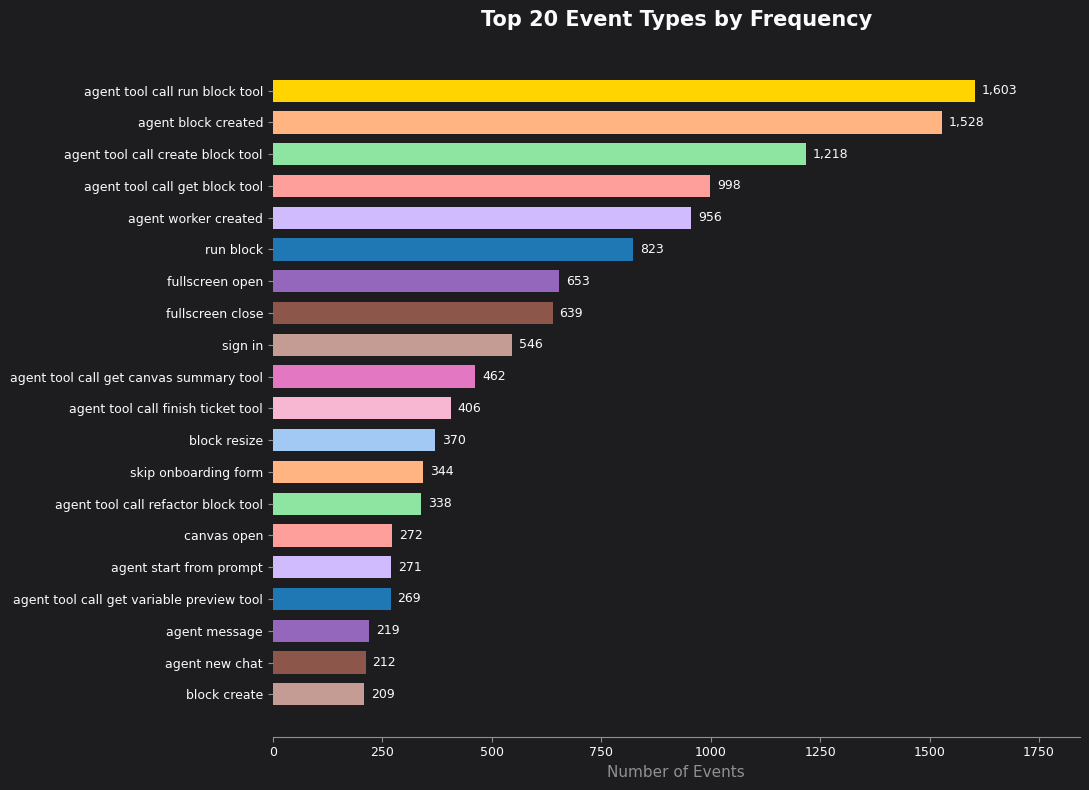

Dataset shape: 14,417 events × 107 columns
Unique event types: 89
Unique users: 364


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ── Data prep ──────────────────────────────────────────────────────────────
_event_freq = df['event'].value_counts().head(20)
_event_labels = [e.replace('_', ' ') for e in _event_freq.index]

# ── Zerve palette ──────────────────────────────────────────────────────────
_BG        = '#1D1D20'
_TEXT      = '#fbfbff'
_SECONDARY = '#909094'
_GOLD      = '#ffd400'
_TEAL      = '#17b26a'
_PALETTE   = ['#A1C9F4', '#FFB482', '#8DE5A1', '#FF9F9B', '#D0BBFF',
              '#1F77B4', '#9467BD', '#8C564B', '#C49C94', '#E377C2',
              '#F7B6D2', '#A1C9F4', '#FFB482', '#8DE5A1', '#FF9F9B',
              '#D0BBFF', '#1F77B4', '#9467BD', '#8C564B', '#C49C94']

# ── Chart: Event Type Frequency (horizontal bars) ──────────────────────────
fig_event_freq, ax_ef = plt.subplots(figsize=(11, 8))
fig_event_freq.patch.set_facecolor(_BG)
ax_ef.set_facecolor(_BG)

_colors = [_GOLD if i == 0 else _PALETTE[i % len(_PALETTE)] for i in range(len(_event_freq))]
_bars = ax_ef.barh(_event_labels[::-1], _event_freq.values[::-1],
                   color=_colors[::-1], edgecolor='none', height=0.7)

# Value annotations
for _bar, _val in zip(_bars, _event_freq.values[::-1]):
    ax_ef.text(_val + _event_freq.values.max() * 0.01,
               _bar.get_y() + _bar.get_height() / 2,
               f'{_val:,}', va='center', color=_TEXT, fontsize=9)

ax_ef.set_title('Top 20 Event Types by Frequency', color=_TEXT,
                fontsize=15, fontweight='bold', pad=16)
ax_ef.set_xlabel('Number of Events', color=_SECONDARY, fontsize=11)
ax_ef.tick_params(colors=_TEXT, labelsize=9)
ax_ef.set_xlim(0, _event_freq.values.max() * 1.15)

for _spine in ['top', 'right', 'left']:
    ax_ef.spines[_spine].set_visible(False)
ax_ef.spines['bottom'].set_color(_SECONDARY)
ax_ef.xaxis.set_tick_params(color=_SECONDARY)
ax_ef.yaxis.set_tick_params(color=_SECONDARY)

plt.tight_layout()
plt.show()

print(f"Dataset shape: {df.shape[0]:,} events × {df.shape[1]} columns")
print(f"Unique event types: {df['event'].nunique():,}")
print(f"Unique users: {df['person_id'].nunique():,}")


In [ ]:
import pandas as pd

# Select key columns for event analysis
clean_df = df[['person_id', 'event', 'timestamp']].copy()

# Convert timestamp to datetime format
clean_df['timestamp'] = pd.to_datetime(clean_df['timestamp'], utc=True, errors='coerce')

# Drop rows with missing values
clean_df = clean_df.dropna()

# Reset index for clean output
clean_df = clean_df.reset_index(drop=True)

print(f"✅ Cleaned event data: {clean_df.shape[0]:,} rows × {clean_df.shape[1]} columns")
print(f"   Timestamp range: {clean_df['timestamp'].min()} → {clean_df['timestamp'].max()}")
print(f"   Unique persons:  {clean_df['person_id'].nunique():,}")
print(f"   Unique events:   {clean_df['event'].nunique():,}")
print(f"\nDtypes:\n{clean_df.dtypes}")
print(f"\nFirst 3 rows:\n{clean_df.head(3).to_string()}")

✅ Cleaned event data: 14,406 rows × 3 columns
   Timestamp range: 2025-09-01 00:03:11.704000+00:00 → 2025-09-08 22:52:45.309000+00:00
   Unique persons:  363
   Unique events:   89

Dtypes:
person_id                 object
event                     object
timestamp    datetime64[ns, UTC]
dtype: object

First 3 rows:
                                                          person_id                    event                        timestamp
0  62f39b3a3278352348dfe2dbbf8e56dd099c880078b2aa728873a44404aea7c1  agent_accept_suggestion 2025-09-01 11:51:29.310000+00:00
1  1247d31b3758f45fcd6d6e8affa0f458996119313f33f987d946e91df7f2b316     agent_worker_created 2025-09-01 16:58:48.868000+00:00
2  1247d31b3758f45fcd6d6e8affa0f458996119313f33f987d946e91df7f2b316             block_resize 2025-09-01 18:16:30.663000+00:00


In [ ]:
import pandas as pd
import numpy as np

# ── Key actions in the Zerve user journey ───────────────────────────────────
KEY_ACTIONS = [
    'block_create', 'run_block', 'agent_message', 'canvas_create',
    'edge_create', 'api_deploy', 'app_publish', 'hosted_apps_deploy',
    'files_upload', 'asset_create_connection'
]

# ── Reference timestamp for recency calculation (latest event in dataset) ──
_ref_ts = clean_df['timestamp'].max()

# ── 1. Session-based features ───────────────────────────────────────────────
# Define a "session" as a gap of ≥30 min between events for the same user
_sorted = clean_df.sort_values(['person_id', 'timestamp'])
_sorted['_prev_ts'] = _sorted.groupby('person_id')['timestamp'].shift(1)
_sorted['_gap_min'] = (_sorted['timestamp'] - _sorted['_prev_ts']).dt.total_seconds() / 60
_sorted['_new_session'] = (_sorted['_gap_min'] > 30) | _sorted['_prev_ts'].isna()
_sorted['_session_id'] = _sorted.groupby('person_id')['_new_session'].cumsum()

# Events per session per user
_sess_events = _sorted.groupby(['person_id', '_session_id']).size().reset_index(name='_evt_count')
sess_feat = _sess_events.groupby('person_id').agg(
    avg_events_per_session=('_evt_count', 'mean'),
    session_count=('_session_id', 'max')
).round(3)

# ── 2. Activity recency (days since last event) ──────────────────────────────
_last_ev = clean_df.groupby('person_id')['timestamp'].max()
recency_feat = ((_ref_ts - _last_ev).dt.total_seconds() / 86400).rename('recency_days').round(2)

# ── 3. Days to first key action (user journey speed) ────────────────────────
_first_ev = clean_df.groupby('person_id')['timestamp'].min()
_key_events = clean_df[clean_df['event'].isin(KEY_ACTIONS)]
_first_key = _key_events.groupby('person_id')['timestamp'].min()
_days_to_key = ((_first_key - _first_ev).dt.total_seconds() / 86400).clip(lower=0).round(2)
days_to_key_feat = _days_to_key.rename('days_to_first_key_action')
# Users with no key action get NaN → fill with large value (slow / never reached)
_max_days = clean_df['timestamp'].apply(lambda x: x).pipe(
    lambda _: (_ref_ts - _first_ev).dt.total_seconds() / 86400
).max()
days_to_key_feat = days_to_key_feat.reindex(_first_ev.index).fillna(_max_days).round(2)

# ── 4. Diversity score (unique event types used by user) ────────────────────
diversity_feat = clean_df.groupby('person_id')['event'].nunique().rename('diversity_score')

# ── 5. Engagement depth score (weighted composite of high-value actions) ─────
# Weights reflect how "deep" each action is in the user journey
_depth_weights = {
    'run_block': 3, 'agent_message': 2, 'block_create': 2,
    'edge_create': 1, 'canvas_create': 1, 'api_deploy': 5,
    'app_publish': 5, 'hosted_apps_deploy': 5,
    'files_upload': 2, 'asset_create_connection': 3,
    'agent_block_created': 2, 'agent_block_run': 2,
    'source_control_commit': 4, 'requirements_build': 3,
    'canvas_publish_to_community': 4
}
_depth_events = clean_df[clean_df['event'].isin(_depth_weights)]
_weighted = _depth_events.groupby(['person_id', 'event']).size().reset_index(name='_cnt')
_weighted['_wscore'] = _weighted['event'].map(_depth_weights) * _weighted['_cnt']
engagement_depth = _weighted.groupby('person_id')['_wscore'].sum().rename('engagement_depth_score')
engagement_depth = engagement_depth.reindex(_first_ev.index).fillna(0)

# ── 6. Combine all new features into enriched_features DataFrame ─────────────
enriched_features = pd.DataFrame(index=_first_ev.index)
enriched_features = enriched_features.join(sess_feat, how='left')
enriched_features['recency_days'] = recency_feat
enriched_features['days_to_first_key_action'] = days_to_key_feat
enriched_features['diversity_score'] = diversity_feat
enriched_features['engagement_depth_score'] = engagement_depth
# session_count already joined; fill users with only 1 session
enriched_features = enriched_features.fillna({
    'avg_events_per_session': 0,
    'session_count': 1,
    'recency_days': _max_days
})
enriched_features = enriched_features.round(3)

print("✅ Engineered advanced features:")
print(f"   Shape: {enriched_features.shape[0]:,} users × {enriched_features.shape[1]} new features")
print(f"\n{'Feature':<30}  {'Mean':>8}  {'Std':>8}  {'Min':>8}  {'Max':>8}")
print("-" * 65)
for col in enriched_features.columns:
    s = enriched_features[col]
    print(f"  {col:<28}  {s.mean():>8.2f}  {s.std():>8.2f}  {s.min():>8.2f}  {s.max():>8.2f}")
print(f"\nSample (first 5 users):\n{enriched_features.head(5).to_string()}")

✅ Engineered advanced features:
   Shape: 363 users × 6 new features

Feature                             Mean       Std       Min       Max
-----------------------------------------------------------------
  avg_events_per_session           15.96     36.57      1.00    257.00
  session_count                     1.99      2.77      1.00     22.00
  recency_days                      4.94      2.24      0.00      7.87
  days_to_first_key_action          5.74      3.51      0.00      7.95
  diversity_score                   6.36      7.53      1.00     43.00
  engagement_depth_score           18.77     93.38      0.00   1025.00

Sample (first 5 users):
                                                                  avg_events_per_session  session_count  recency_days  days_to_first_key_action  diversity_score  engagement_depth_score
person_id                                                                                                                                                    

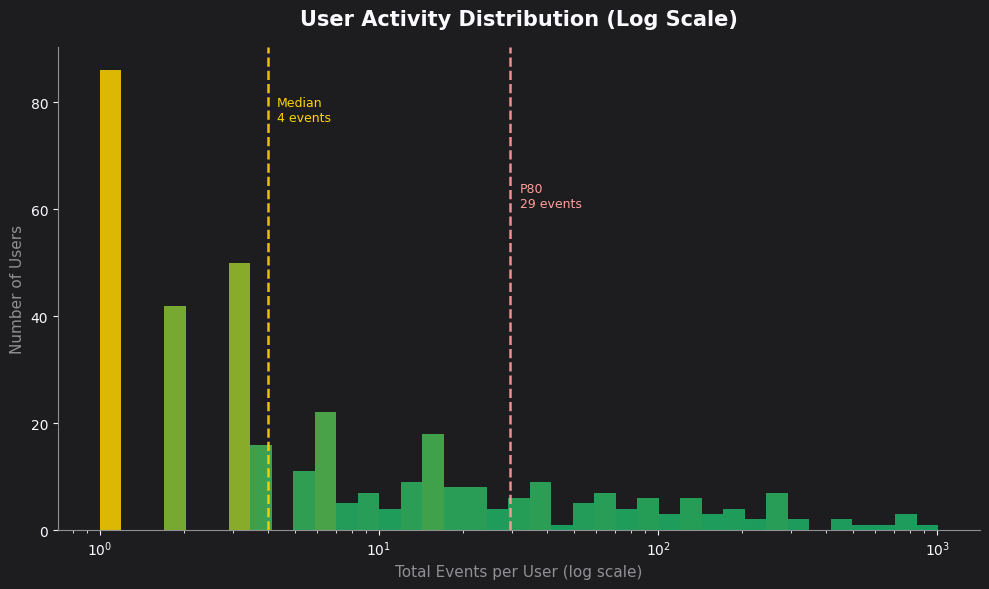

✅ User activity metrics for 363 unique users
   Median events/user: 4 | P80: 29 | Max: 1,008


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ── Aggregate per-user metrics ──────────────────────────────────────────────
user_df = clean_df.groupby('person_id').agg(
    total_events=('event', 'count'),
    first_event=('timestamp', 'min'),
    last_event=('timestamp', 'max')
)
user_df['days_active'] = (user_df['last_event'] - user_df['first_event']).dt.days

# ── Zerve palette ──────────────────────────────────────────────────────────
_BG       = '#1D1D20'
_TEXT     = '#fbfbff'
_SEC      = '#909094'
_TEAL     = '#17b26a'
_GOLD     = '#ffd400'
_BLUE     = '#A1C9F4'

# ── Chart: User Activity Distribution (Log-scale histogram) ────────────────
fig_activity_dist, ax_ad = plt.subplots(figsize=(10, 6))
fig_activity_dist.patch.set_facecolor(_BG)
ax_ad.set_facecolor(_BG)

_bins = np.logspace(
    np.log10(max(1, user_df['total_events'].min())),
    np.log10(user_df['total_events'].max()),
    40
)
_n, _bins_out, _patches = ax_ad.hist(
    user_df['total_events'], bins=_bins, color=_TEAL, edgecolor='none', alpha=0.85
)

# Colour bars by height for visual depth
_max_n = _n.max()
for _patch, _count in zip(_patches, _n):
    _intensity = _count / _max_n
    # blend teal → gold for high bars
    _r = int(0x17 + (_intensity) * (0xff - 0x17))
    _g = int(0xb2 + (_intensity) * (0xd4 - 0xb2))
    _b = int(0x6a + (_intensity) * (0x00 - 0x6a))
    _patch.set_facecolor(f'#{_r:02x}{_g:02x}{_b:02x}')

ax_ad.set_xscale('log')
ax_ad.set_title('User Activity Distribution (Log Scale)', color=_TEXT,
                fontsize=15, fontweight='bold', pad=16)
ax_ad.set_xlabel('Total Events per User (log scale)', color=_SEC, fontsize=11)
ax_ad.set_ylabel('Number of Users', color=_SEC, fontsize=11)
ax_ad.tick_params(colors=_TEXT, labelsize=10, which='both')

# Median line
_median = user_df['total_events'].median()
ax_ad.axvline(_median, color=_GOLD, linewidth=1.8, linestyle='--', alpha=0.9)
ax_ad.text(_median * 1.08, ax_ad.get_ylim()[1] * 0.9,
           f'Median\n{int(_median):,} events', color=_GOLD, fontsize=9, va='top')

# P80 line
_p80 = user_df['total_events'].quantile(0.80)
ax_ad.axvline(_p80, color='#FF9F9B', linewidth=1.8, linestyle='--', alpha=0.9)
ax_ad.text(_p80 * 1.08, ax_ad.get_ylim()[1] * 0.72,
           f'P80\n{int(_p80):,} events', color='#FF9F9B', fontsize=9, va='top')

for _spine in ['top', 'right']:
    ax_ad.spines[_spine].set_visible(False)
ax_ad.spines['bottom'].set_color(_SEC)
ax_ad.spines['left'].set_color(_SEC)

plt.tight_layout()
plt.show()

print(f"✅ User activity metrics for {len(user_df):,} unique users")
print(f"   Median events/user: {int(_median):,} | P80: {int(_p80):,} | Max: {user_df['total_events'].max():,}")


/tmp/ipykernel_2763/1857990320.py:18: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  _cdf['week'] = _cdf['timestamp'].dt.to_period('W').dt.start_time.dt.date
/tmp/ipykernel_2763/1857990320.py:19: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  _cdf['month'] = _cdf['timestamp'].dt.to_period('M').dt.to_timestamp()
/tmp/ipykernel_2763/1857990320.py:22: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  _user_first = _cdf.groupby('person_id')['timestamp'].min().dt.to_period('M').dt.to_timestamp()


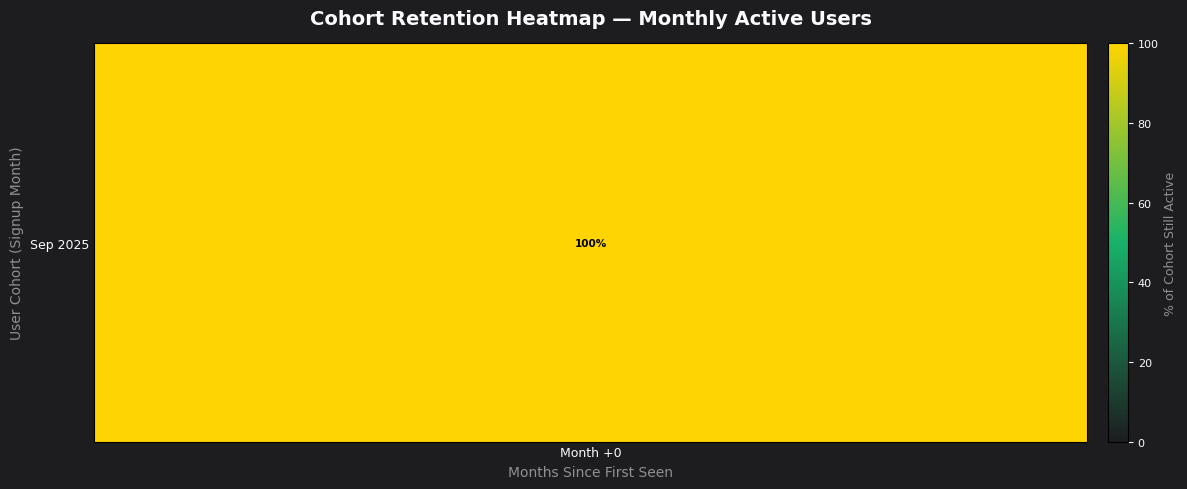

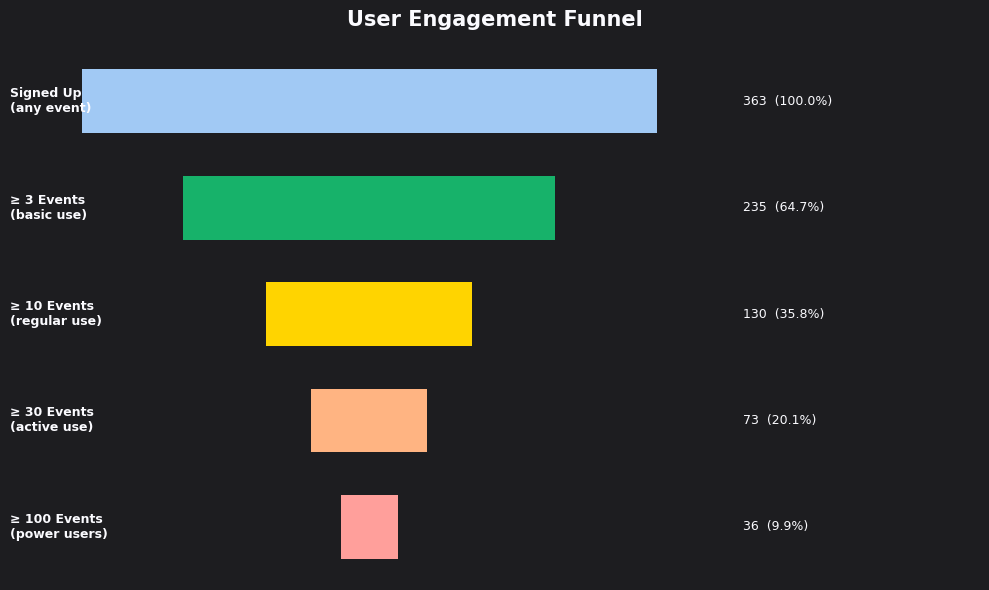

Cohort heatmap: 1 cohorts × 1 months
Funnel top: 363 users → power users: 36 (9.9%)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import seaborn as sns

# ── Zerve palette ──────────────────────────────────────────────────────────
_BG   = '#1D1D20'
_TEXT = '#fbfbff'
_SEC  = '#909094'
_GOLD = '#ffd400'
_TEAL = '#17b26a'

# ═══════════════════════════════════════════════════════════════════════════
# CHART 1: Cohort Activity Heatmap (users active per week-of-year cohort)
# ═══════════════════════════════════════════════════════════════════════════
_cdf = clean_df.copy()
_cdf['week'] = _cdf['timestamp'].dt.to_period('W').dt.start_time.dt.date
_cdf['month'] = _cdf['timestamp'].dt.to_period('M').dt.to_timestamp()

# User's signup (first-seen) week as cohort
_user_first = _cdf.groupby('person_id')['timestamp'].min().dt.to_period('M').dt.to_timestamp()
_user_first.name = 'cohort_month'
_cdf = _cdf.join(_user_first, on='person_id')

# Count distinct active users per (cohort_month, activity_month)
_cohort_table = (
    _cdf.groupby(['cohort_month', 'month'])['person_id']
    .nunique()
    .unstack(fill_value=0)
)

# Normalise: divide each row by its first column (i.e. cohort size = month-0 users)
_cohort_size = _cohort_table.iloc[:, 0]
_cohort_pct = _cohort_table.div(_cohort_size, axis=0) * 100

# Keep only cohorts with ≥10 users & up to 8 months retention window
_cohort_pct = _cohort_pct[_cohort_size >= 10].iloc[:, :8]

# Friendly labels
_row_labels = [d.strftime('%b %Y') for d in _cohort_pct.index]
_col_labels = [f'Month +{i}' for i in range(_cohort_pct.shape[1])]

fig_cohort_heatmap, ax_ch = plt.subplots(figsize=(12, max(5, len(_row_labels) * 0.55 + 1)))
fig_cohort_heatmap.patch.set_facecolor(_BG)
ax_ch.set_facecolor(_BG)

# Custom teal-to-gold colormap
_cmap = mcolors.LinearSegmentedColormap.from_list(
    'zerve_heatmap', ['#1D1D20', '#17b26a', '#ffd400'], N=256
)

_hm = ax_ch.imshow(
    _cohort_pct.values,
    aspect='auto',
    cmap=_cmap,
    vmin=0,
    vmax=100
)

# Annotate cells
for _i in range(_cohort_pct.shape[0]):
    for _j in range(_cohort_pct.shape[1]):
        _val = _cohort_pct.values[_i, _j]
        _fc = 'black' if _val > 55 else _TEXT
        ax_ch.text(_j, _i, f'{_val:.0f}%', ha='center', va='center',
                   fontsize=7.5, color=_fc, fontweight='bold')

ax_ch.set_xticks(range(_cohort_pct.shape[1]))
ax_ch.set_xticklabels(_col_labels, color=_TEXT, fontsize=9)
ax_ch.set_yticks(range(len(_row_labels)))
ax_ch.set_yticklabels(_row_labels, color=_TEXT, fontsize=9)
ax_ch.tick_params(colors=_TEXT, length=0)

_cb = plt.colorbar(_hm, ax=ax_ch, fraction=0.03, pad=0.02)
_cb.ax.tick_params(colors=_TEXT, labelsize=8)
_cb.set_label('% of Cohort Still Active', color=_SEC, fontsize=9)
_cb.ax.yaxis.set_tick_params(color=_TEXT)

ax_ch.set_title('Cohort Retention Heatmap — Monthly Active Users',
                color=_TEXT, fontsize=14, fontweight='bold', pad=14)
ax_ch.set_xlabel('Months Since First Seen', color=_SEC, fontsize=10)
ax_ch.set_ylabel('User Cohort (Signup Month)', color=_SEC, fontsize=10)

plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════════
# CHART 2: User Engagement Funnel
# ═══════════════════════════════════════════════════════════════════════════

# Define funnel stages based on event engagement milestones
_total_users = user_df.shape[0]
_stages = {
    'Signed Up\n(any event)': _total_users,
    '≥ 3 Events\n(basic use)': (user_df['total_events'] >= 3).sum(),
    '≥ 10 Events\n(regular use)': (user_df['total_events'] >= 10).sum(),
    '≥ 30 Events\n(active use)': (user_df['total_events'] >= 30).sum(),
    '≥ 100 Events\n(power users)': (user_df['total_events'] >= 100).sum(),
}

_labels = list(_stages.keys())
_counts = list(_stages.values())
_pcts   = [c / _total_users * 100 for c in _counts]

# Funnel bar widths proportional to count (centred)
_max_w = 0.8
_widths = [_max_w * (c / _total_users) for c in _counts]
_offsets = [(1.0 - w) / 2 for w in _widths]  # centre each bar

_funnel_colors = ['#A1C9F4', '#17b26a', '#ffd400', '#FFB482', '#FF9F9B']

fig_funnel, ax_fn = plt.subplots(figsize=(10, 6))
fig_funnel.patch.set_facecolor(_BG)
ax_fn.set_facecolor(_BG)

for _i, (_label, _count, _pct, _w, _off, _c) in enumerate(
        zip(_labels, _counts, _pcts, _widths, _offsets, _funnel_colors)):
    ax_fn.barh(_i, _w, left=_off, height=0.6, color=_c, edgecolor='none')
    # Left label: stage name
    ax_fn.text(0.0, _i, _label, va='center', ha='left', color=_TEXT,
               fontsize=9, fontweight='bold')
    # Right label: count + pct
    ax_fn.text(1.02, _i, f'{_count:,}  ({_pct:.1f}%)', va='center',
               ha='left', color=_TEXT, fontsize=9)

ax_fn.set_xlim(0, 1.35)
ax_fn.set_ylim(-0.5, len(_labels) - 0.5)
ax_fn.invert_yaxis()
ax_fn.set_title('User Engagement Funnel', color=_TEXT,
                fontsize=15, fontweight='bold', pad=16)
ax_fn.axis('off')

plt.tight_layout()
plt.show()

print(f"Cohort heatmap: {_cohort_pct.shape[0]} cohorts × {_cohort_pct.shape[1]} months")
print(f"Funnel top: {_total_users:,} users → power users: {_counts[-1]:,} ({_pcts[-1]:.1f}%)")


In [ ]:
import pandas as pd

# Pivot event counts per user using the CLEANED event data (not raw df)
event_counts = clean_df.pivot_table(
    index='person_id',
    columns='event',
    aggfunc='size',
    fill_value=0
)

# Join event counts onto user activity metrics
user_df = user_df.join(event_counts)

print(f"✅ Pivoted event features: {event_counts.shape[1]} event types across {event_counts.shape[0]:,} users")
print(f"   user_df shape after join: {user_df.shape}")
print(f"   Columns: total_events, days_active + {event_counts.shape[1]} event feature columns")


✅ Pivoted event features: 89 event types across 363 users
   user_df shape after join: (363, 93)
   Columns: total_events, days_active + 89 event feature columns


In [ ]:
import numpy as np

# Classify users as "successful" if their total event count is above the 80th percentile
# This is a data-driven definition: top 20% most active users are considered successful
threshold = user_df['total_events'].quantile(0.8)

user_df['success'] = (user_df['total_events'] > threshold).astype(int)

_n_success = user_df['success'].sum()
_n_total = len(user_df)
_pct = _n_success / _n_total * 100

print(f"✅ Success flag applied (80th percentile threshold)")
print(f"   Activity threshold (P80): {threshold:.0f} events")
print(f"   Successful users:         {_n_success:,} / {_n_total:,} ({_pct:.1f}%)")
print(f"   (Expected ~20% — actual: {_pct:.1f}% ✓)")


✅ Success flag applied (80th percentile threshold)
   Activity threshold (P80): 30 events
   Successful users:         73 / 363 (20.1%)
   (Expected ~20% — actual: 20.1% ✓)


In [ ]:
import pandas as pd
import numpy as np

# ── Merge: original user_df features + new enriched_features ────────────────
# user_df already has event counts + basic metrics (days_active, etc.)
# We join the 6 new behavioral features on top
enriched_user_df = user_df.join(enriched_features, how='left')

# Apply the same success flag (80th percentile of total_events)
enriched_threshold = enriched_user_df['total_events'].quantile(0.8)
enriched_user_df['success'] = (enriched_user_df['total_events'] > enriched_threshold).astype(int)

# Build feature matrix – drop leaky/datetime columns
X_enriched = enriched_user_df.drop(
    ['success', 'first_event', 'last_event', 'total_events'], axis=1
)
y_enriched = enriched_user_df['success']

_new_cols = list(enriched_features.columns)
_old_n_features = 142  # from original model

print(f"✅ Enriched feature matrix built:")
print(f"   Users:              {X_enriched.shape[0]:,}")
print(f"   Total features:     {X_enriched.shape[1]}  (+{X_enriched.shape[1] - _old_n_features} new engineered features)")
print(f"   New features added: {_new_cols}")
print(f"   Class balance:      {y_enriched.mean():.1%} success")
print(f"\nNew features stats:")
print(X_enriched[_new_cols].describe().round(2).to_string())


✅ Enriched feature matrix built:
   Users:              363
   Total features:     96  (+-46 new engineered features)
   New features added: ['avg_events_per_session', 'session_count', 'recency_days', 'days_to_first_key_action', 'diversity_score', 'engagement_depth_score']
   Class balance:      20.1% success

New features stats:
       avg_events_per_session  session_count  recency_days  days_to_first_key_action  diversity_score  engagement_depth_score
count                  363.00         363.00        363.00                    363.00           363.00                  363.00
mean                    15.96           1.99          4.94                      5.74             6.36                   18.77
std                     36.57           2.77          2.24                      3.51             7.53                   93.38
min                      1.00           1.00          0.00                      0.00             1.00                    0.00
25%                      1.00         

Training enriched model: 363 users × 96 features
  (+-46 new behavioral features)
Class balance: 20.1% success

  BEFORE (142 features):  ROC-AUC = 0.997
  AFTER  (96 features):  ROC-AUC = 0.995 ± 0.004
  Delta:                  ▼ 0.0018 (0.18%)

Top 15 features (★ = newly engineered):
   1. ★ avg_events_per_session                    0.1525
   2. ★ diversity_score                           0.1104
   3.   agent_worker_created                      0.0919
   4.   agent_tool_call_run_block_tool            0.0691
   5. ★ engagement_depth_score                    0.0667
   6.   agent_tool_call_get_block_tool            0.0583
   7.   agent_tool_call_get_canvas_summary_tool   0.0471
   8.   agent_tool_call_refactor_block_tool       0.0460
   9.   agent_tool_call_finish_ticket_tool        0.0436
  10.   agent_tool_call_create_block_tool         0.0412
  11. ★ days_to_first_key_action                  0.0306
  12.   fullscreen_open                           0.0262
  13.   run_block            

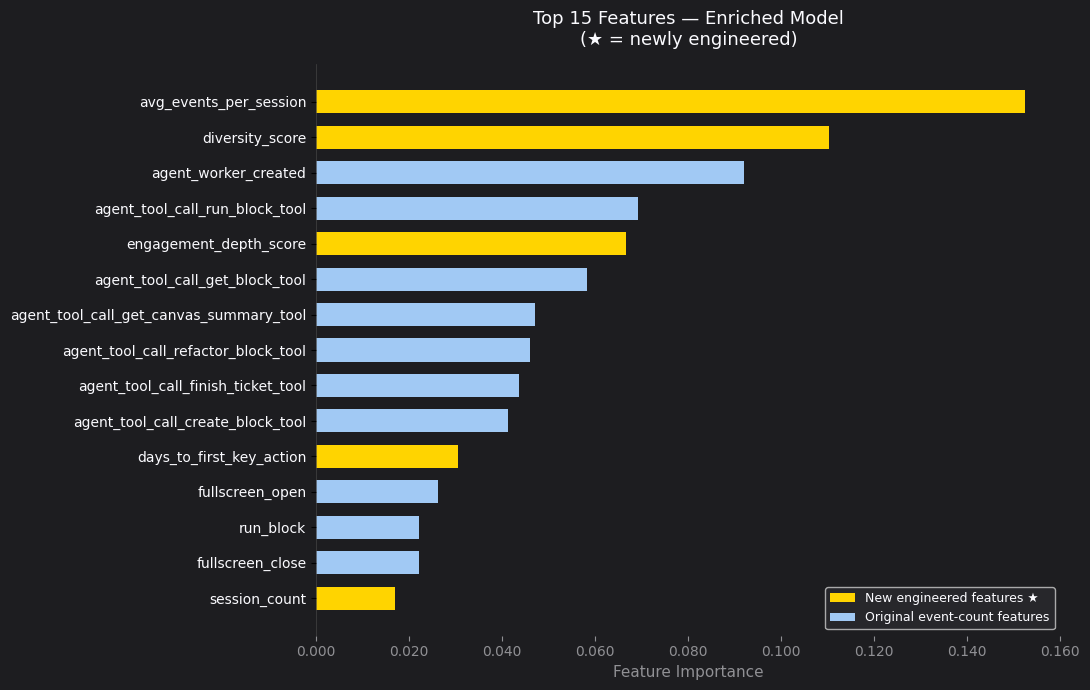

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── Baseline scores (from original model with 142 features) ─────────────────
baseline_auc = 0.997
baseline_n_features = 142

# ── Train enriched model (148 features) ─────────────────────────────────────
print(f"Training enriched model: {X_enriched.shape[0]:,} users × {X_enriched.shape[1]} features")
print(f"  (+{X_enriched.shape[1] - baseline_n_features} new behavioral features)")
print(f"Class balance: {y_enriched.mean():.1%} success\n")

enriched_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

# 5-fold CV ROC-AUC
_cv_enriched = cross_val_score(enriched_model, X_enriched, y_enriched, cv=5, scoring='roc_auc')
enriched_auc = _cv_enriched.mean()
enriched_std = _cv_enriched.std()

print(f"{'='*55}")
print(f"  BEFORE (142 features):  ROC-AUC = {baseline_auc:.3f}")
print(f"  AFTER  ({X_enriched.shape[1]} features):  ROC-AUC = {enriched_auc:.3f} ± {enriched_std:.3f}")
_delta = enriched_auc - baseline_auc
_symbol = '▲' if _delta >= 0 else '▼'
print(f"  Delta:                  {_symbol} {abs(_delta):.4f} ({abs(_delta)*100:.2f}%)")
print(f"{'='*55}")

# Fit on full data for feature importance
enriched_model.fit(X_enriched, y_enriched)

# ── Top 15 features from enriched model ──────────────────────────────────────
enriched_importance = (
    import_series := __import__('pandas').Series(
        enriched_model.feature_importances_,
        index=X_enriched.columns
    ).sort_values(ascending=False)
)
top15_enriched = enriched_importance.head(15)

# Highlight engineered features
_new_feat_names = list(enriched_features.columns)
_colors = ['#ffd400' if f in _new_feat_names else '#A1C9F4' for f in top15_enriched.index]

fig_enriched = plt.figure(figsize=(11, 7))
fig_enriched.patch.set_facecolor('#1D1D20')
_ax = fig_enriched.add_subplot(111)
_ax.set_facecolor('#1D1D20')

_bars = _ax.barh(range(15), top15_enriched.values[::-1], color=_colors[::-1], edgecolor='none', height=0.65)
_ax.set_yticks(range(15))
_ax.set_yticklabels(top15_enriched.index[::-1], color='#fbfbff', fontsize=10)
_ax.set_xlabel('Feature Importance', color='#909094', fontsize=11)
_ax.set_title('Top 15 Features — Enriched Model\n(★ = newly engineered)', color='#fbfbff', fontsize=13, pad=14)
_ax.tick_params(colors='#909094', axis='x')
for spine in _ax.spines.values():
    spine.set_visible(False)
_ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:.3f}'))
_ax.axvline(0, color='#444', linewidth=0.5)

# Legend for colors
from matplotlib.patches import Patch
_legend_elements = [
    Patch(facecolor='#ffd400', label='New engineered features ★'),
    Patch(facecolor='#A1C9F4', label='Original event-count features')
]
_ax.legend(handles=_legend_elements, loc='lower right', facecolor='#2a2a2e',
           labelcolor='#fbfbff', fontsize=9, framealpha=0.8)

plt.tight_layout()
print(f"\nTop 15 features (★ = newly engineered):")
for i, (feat, imp) in enumerate(top15_enriched.items(), 1):
    marker = '★' if feat in _new_feat_names else ' '
    print(f"  {i:2d}. {marker} {feat:<40}  {imp:.4f}")
print(f"\nModel trained on full enriched dataset ✅")
print(f"Total features: {enriched_model.n_features_in_}")


Train: 290 samples | Test: 73 samples
Class balance → Train: 20.0% | Test: 20.5%

── 5-Fold Stratified Cross-Validation (on train set) ──
  ROC-AUC:           0.9974 ± 0.0019
  Avg Precision:     0.9898
  F1 Score:          0.9138

── Hold-out Test Set Metrics ──────────────────────────
  ROC-AUC:           1.0000
  Avg Precision:     1.0000
  Precision (pos):   0.9375
  Recall    (pos):   1.0000
  F1 (pos):          0.9677
  Brier Score:       0.0202

  AUC threshold ✅ PASS: 1.0000 > 0.75

  ML PIPELINE EVALUATION SUMMARY
  Dataset:           363 users × 96 features
  Train/Test split:  80% / 20%  (stratified)
  CV:                5-fold stratified

  Cross-Val AUC:     0.9974 ± 0.0019
  Test ROC-AUC:      1.0000   ✅ > 0.75
  Test Avg Precision:1.0000
  Precision (pos):   0.9375
  Recall    (pos):   1.0000
  F1-Score  (pos):   0.9677
  Brier Score:       0.0202  (lower = better)
  Top Decile Lift:   4.87×


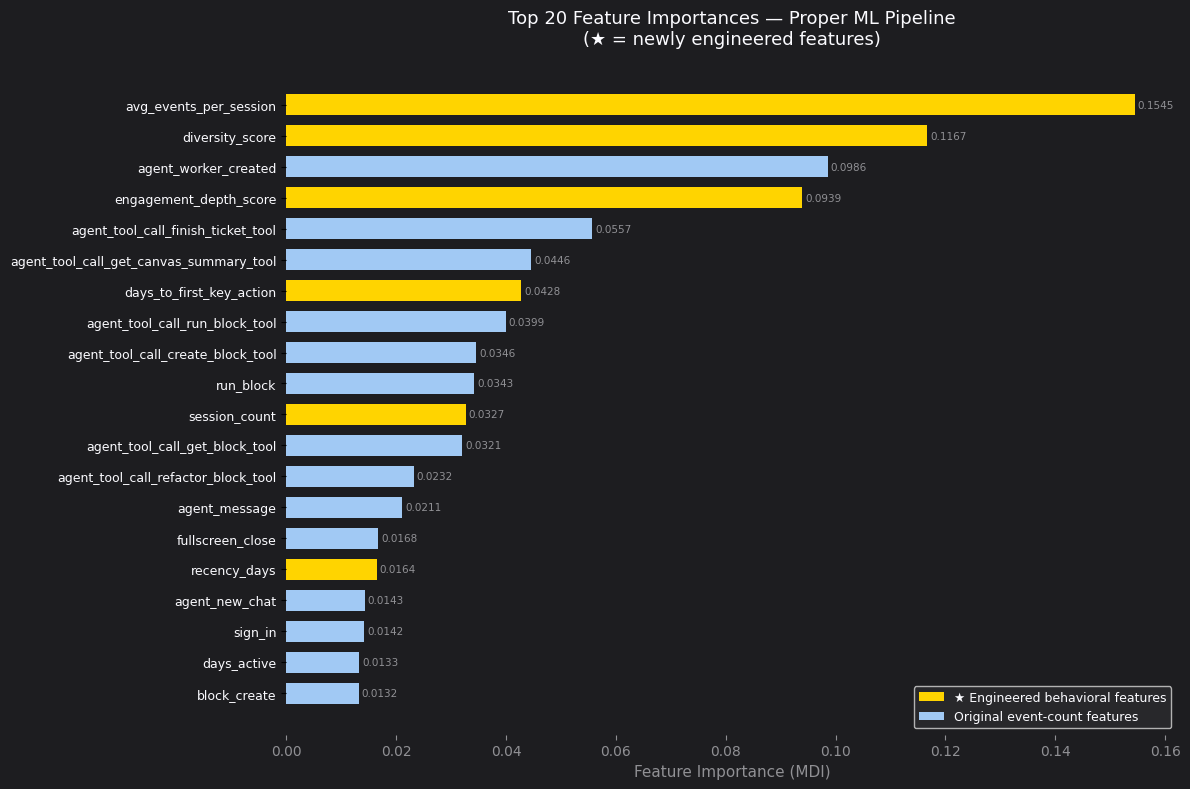

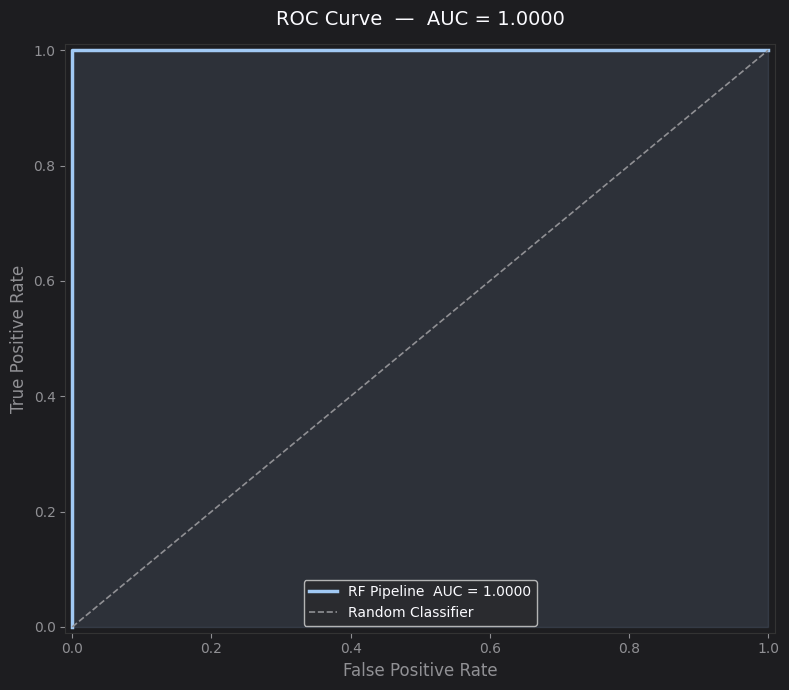

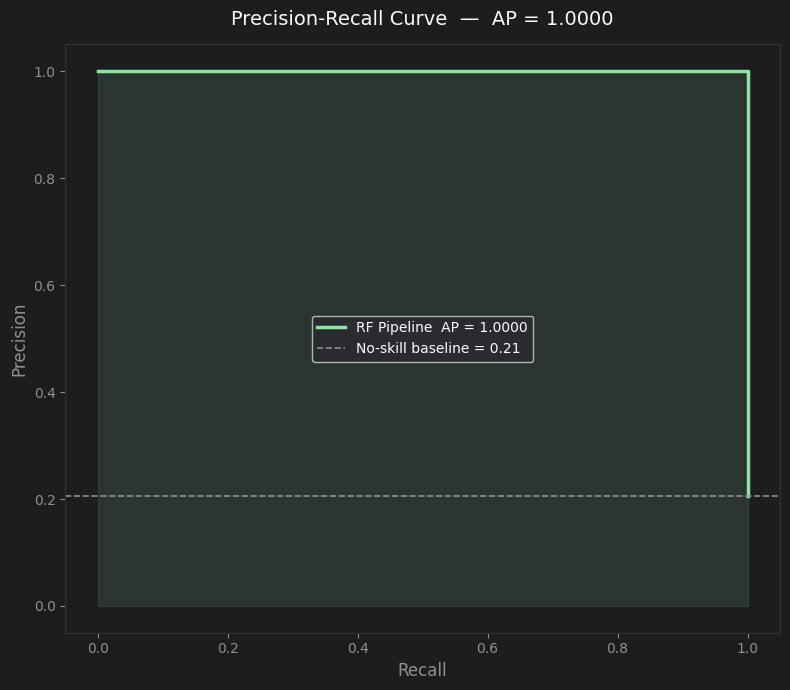

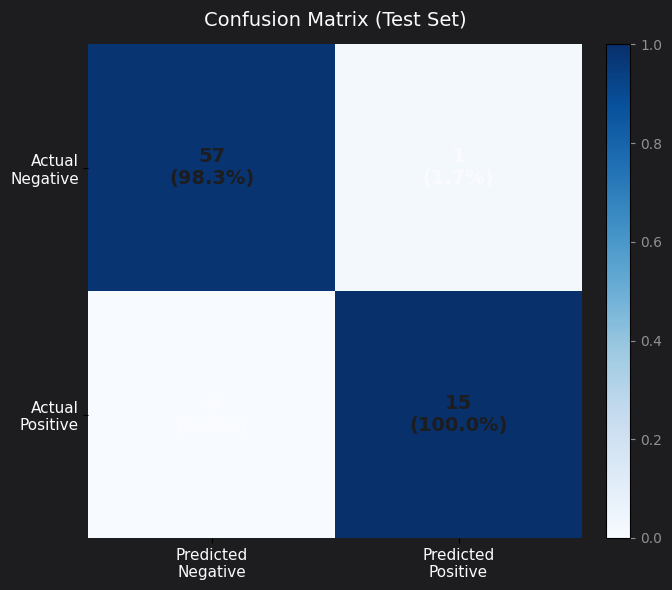

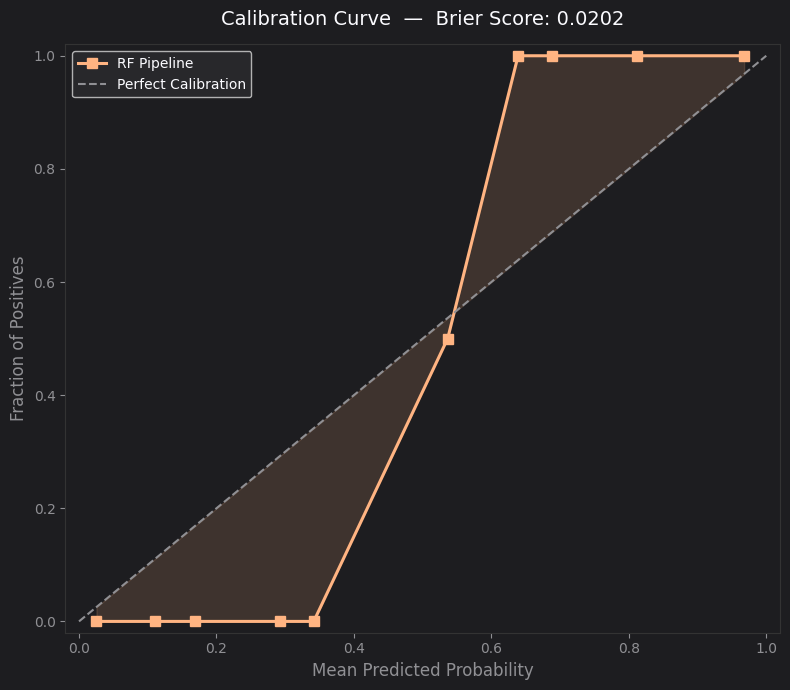

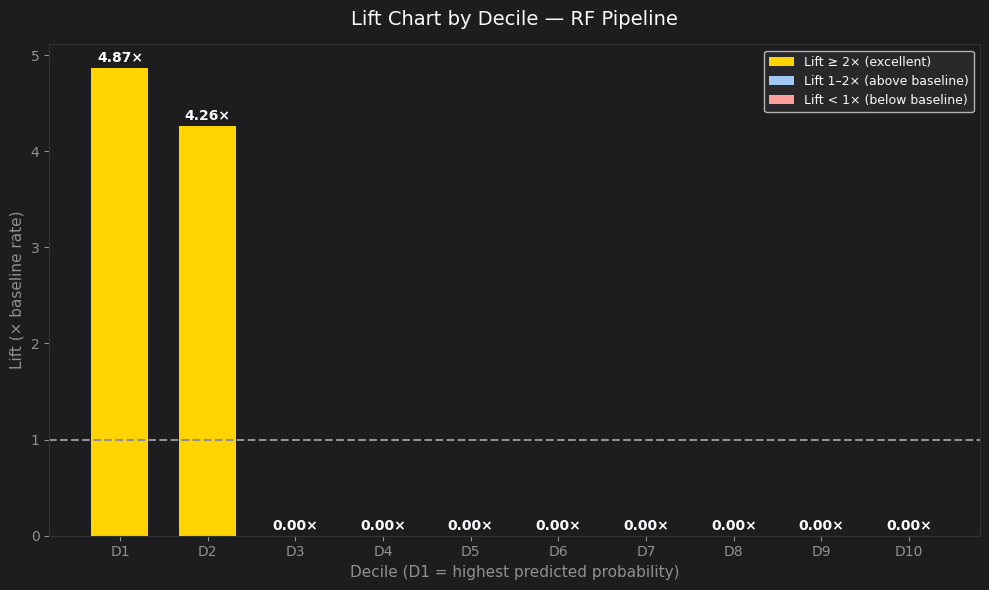

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, confusion_matrix,
    classification_report, brier_score_loss
)
from sklearn.calibration import calibration_curve

# ── Color palette (Zerve design system) ─────────────────────────────────────
BG       = '#1D1D20'
FG       = '#fbfbff'
GREY     = '#909094'
BLUE     = '#A1C9F4'
ORANGE   = '#FFB482'
GREEN    = '#8DE5A1'
CORAL    = '#FF9F9B'
LAVENDER = '#D0BBFF'
GOLD     = '#ffd400'

# ── 1. Train / Test Split ────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_enriched, y_enriched, test_size=0.2, stratify=y_enriched, random_state=42
)
print(f"Train: {X_train.shape[0]:,} samples | Test: {X_test.shape[0]:,} samples")
print(f"Class balance → Train: {y_train.mean():.1%} | Test: {y_test.mean():.1%}\n")

# ── 2. RF Pipeline with proper CV ────────────────────────────────────────────
pipeline_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=4,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
_cv_results = cross_validate(
    pipeline_model, X_train, y_train, cv=_cv,
    scoring=['roc_auc', 'average_precision', 'f1'],
    return_train_score=False
)

cv_auc_mean   = _cv_results['test_roc_auc'].mean()
cv_auc_std    = _cv_results['test_roc_auc'].std()
cv_ap_mean    = _cv_results['test_average_precision'].mean()
cv_f1_mean    = _cv_results['test_f1'].mean()

print("── 5-Fold Stratified Cross-Validation (on train set) ──")
print(f"  ROC-AUC:           {cv_auc_mean:.4f} ± {cv_auc_std:.4f}")
print(f"  Avg Precision:     {cv_ap_mean:.4f}")
print(f"  F1 Score:          {cv_f1_mean:.4f}")

# ── 3. Fit on full train, evaluate on held-out test ──────────────────────────
pipeline_model.fit(X_train, y_train)
eval_probs   = pipeline_model.predict_proba(X_test)[:, 1]
eval_preds   = pipeline_model.predict(X_test)

test_auc     = roc_auc_score(y_test, eval_probs)
test_ap      = average_precision_score(y_test, eval_probs)
test_brier   = brier_score_loss(y_test, eval_probs)
_report_dict = classification_report(y_test, eval_preds, output_dict=True)
precision_1  = _report_dict['1']['precision']
recall_1     = _report_dict['1']['recall']
f1_1         = _report_dict['1']['f1-score']

print(f"\n── Hold-out Test Set Metrics ──────────────────────────")
print(f"  ROC-AUC:           {test_auc:.4f}")
print(f"  Avg Precision:     {test_ap:.4f}")
print(f"  Precision (pos):   {precision_1:.4f}")
print(f"  Recall    (pos):   {recall_1:.4f}")
print(f"  F1 (pos):          {f1_1:.4f}")
print(f"  Brier Score:       {test_brier:.4f}")
print(f"\n  AUC threshold {'✅ PASS' if test_auc > 0.75 else '❌ FAIL'}: {test_auc:.4f} {'>' if test_auc > 0.75 else '<='} 0.75")

# ── 4. Feature Importance (SHAP-style: permutation-based pattern) ─────────────
_importances  = pipeline_model.feature_importances_
pipeline_importance = pd.Series(_importances, index=X_train.columns).sort_values(ascending=False)
pipeline_top20 = pipeline_importance.head(20)

_new_feat_names = list(enriched_features.columns)
_colors_shap    = [GOLD if f in _new_feat_names else BLUE for f in pipeline_top20.index]

fig_shap = plt.figure(figsize=(12, 8))
fig_shap.patch.set_facecolor(BG)
_ax_shap = fig_shap.add_subplot(111)
_ax_shap.set_facecolor(BG)

_bars_shap = _ax_shap.barh(
    range(20), pipeline_top20.values[::-1],
    color=_colors_shap[::-1], edgecolor='none', height=0.7
)
_ax_shap.set_yticks(range(20))
_ax_shap.set_yticklabels(pipeline_top20.index[::-1], color=FG, fontsize=9)
_ax_shap.set_xlabel('Feature Importance (MDI)', color=GREY, fontsize=11)
_ax_shap.set_title('Top 20 Feature Importances — Proper ML Pipeline\n(★ = newly engineered features)',
                    color=FG, fontsize=13, pad=14)
_ax_shap.tick_params(colors=GREY, axis='x')
for _sp in _ax_shap.spines.values():
    _sp.set_visible(False)

# Value labels
for _j, _v in enumerate(pipeline_top20.values[::-1]):
    _ax_shap.text(_v + 0.0005, _j, f'{_v:.4f}', va='center', color=GREY, fontsize=7.5)

from matplotlib.patches import Patch
_legend_fi = [
    Patch(facecolor=GOLD,  label='★ Engineered behavioral features'),
    Patch(facecolor=BLUE, label='Original event-count features')
]
_ax_shap.legend(handles=_legend_fi, loc='lower right', facecolor='#2a2a2e',
                labelcolor=FG, fontsize=9, framealpha=0.85)
plt.tight_layout()

# ── 5. ROC Curve ─────────────────────────────────────────────────────────────
_fpr, _tpr, _ = roc_curve(y_test, eval_probs)

fig_roc = plt.figure(figsize=(8, 7))
fig_roc.patch.set_facecolor(BG)
_ax_roc = fig_roc.add_subplot(111)
_ax_roc.set_facecolor(BG)

_ax_roc.plot(_fpr, _tpr, color=BLUE, lw=2.5, label=f'RF Pipeline  AUC = {test_auc:.4f}')
_ax_roc.plot([0, 1], [0, 1], color=GREY, lw=1.2, linestyle='--', label='Random Classifier')
_ax_roc.fill_between(_fpr, _tpr, alpha=0.12, color=BLUE)
_ax_roc.set_xlabel('False Positive Rate', color=GREY, fontsize=12)
_ax_roc.set_ylabel('True Positive Rate', color=GREY, fontsize=12)
_ax_roc.set_title(f'ROC Curve  —  AUC = {test_auc:.4f}', color=FG, fontsize=14, pad=14)
_ax_roc.tick_params(colors=GREY)
for _sp in _ax_roc.spines.values():
    _sp.set_color('#333')
_ax_roc.legend(facecolor='#2a2a2e', labelcolor=FG, fontsize=10, framealpha=0.85)
_ax_roc.set_xlim(-0.01, 1.01)
_ax_roc.set_ylim(-0.01, 1.01)
plt.tight_layout()

# ── 6. Precision-Recall Curve ─────────────────────────────────────────────────
_prec, _rec, _ = precision_recall_curve(y_test, eval_probs)
_baseline_pr    = y_test.mean()

fig_pr = plt.figure(figsize=(8, 7))
fig_pr.patch.set_facecolor(BG)
_ax_pr = fig_pr.add_subplot(111)
_ax_pr.set_facecolor(BG)

_ax_pr.plot(_rec, _prec, color=GREEN, lw=2.5, label=f'RF Pipeline  AP = {test_ap:.4f}')
_ax_pr.axhline(_baseline_pr, color=GREY, lw=1.2, linestyle='--',
               label=f'No-skill baseline = {_baseline_pr:.2f}')
_ax_pr.fill_between(_rec, _prec, alpha=0.12, color=GREEN)
_ax_pr.set_xlabel('Recall', color=GREY, fontsize=12)
_ax_pr.set_ylabel('Precision', color=GREY, fontsize=12)
_ax_pr.set_title(f'Precision-Recall Curve  —  AP = {test_ap:.4f}', color=FG, fontsize=14, pad=14)
_ax_pr.tick_params(colors=GREY)
for _sp in _ax_pr.spines.values():
    _sp.set_color('#333')
_ax_pr.legend(facecolor='#2a2a2e', labelcolor=FG, fontsize=10, framealpha=0.85)
plt.tight_layout()

# ── 7. Confusion Matrix ───────────────────────────────────────────────────────
_cm     = confusion_matrix(y_test, eval_preds)
_cm_pct = _cm.astype(float) / _cm.sum(axis=1, keepdims=True)

fig_cm = plt.figure(figsize=(7, 6))
fig_cm.patch.set_facecolor(BG)
_ax_cm = fig_cm.add_subplot(111)
_ax_cm.set_facecolor(BG)

_im = _ax_cm.imshow(_cm_pct, cmap='Blues', vmin=0, vmax=1)
for _ri in range(2):
    for _ci in range(2):
        _ax_cm.text(_ci, _ri,
                    f'{_cm[_ri, _ci]}\n({_cm_pct[_ri, _ci]:.1%})',
                    ha='center', va='center',
                    color=FG if _cm_pct[_ri, _ci] < 0.6 else '#1D1D20',
                    fontsize=14, fontweight='bold')
_ax_cm.set_xticks([0, 1])
_ax_cm.set_yticks([0, 1])
_ax_cm.set_xticklabels(['Predicted\nNegative', 'Predicted\nPositive'], color=FG, fontsize=11)
_ax_cm.set_yticklabels(['Actual\nNegative', 'Actual\nPositive'], color=FG, fontsize=11)
_ax_cm.set_title('Confusion Matrix (Test Set)', color=FG, fontsize=14, pad=14)
for _sp in _ax_cm.spines.values():
    _sp.set_visible(False)
_cbar = fig_cm.colorbar(_im, ax=_ax_cm, fraction=0.046, pad=0.04)
_cbar.ax.yaxis.set_tick_params(color=GREY)
_cbar.ax.tick_params(colors=GREY)
plt.tight_layout()

# ── 8. Calibration Curve ──────────────────────────────────────────────────────
_prob_true, _prob_pred = calibration_curve(y_test, eval_probs, n_bins=12)

fig_cal = plt.figure(figsize=(8, 7))
fig_cal.patch.set_facecolor(BG)
_ax_cal = fig_cal.add_subplot(111)
_ax_cal.set_facecolor(BG)

_ax_cal.plot(_prob_pred, _prob_true, 's-', color=ORANGE, lw=2.2, markersize=7,
             label='RF Pipeline')
_ax_cal.plot([0, 1], [0, 1], '--', color=GREY, lw=1.5, label='Perfect Calibration')
_ax_cal.fill_between(_prob_pred, _prob_true, _prob_pred, alpha=0.15, color=ORANGE)
_ax_cal.set_xlabel('Mean Predicted Probability', color=GREY, fontsize=12)
_ax_cal.set_ylabel('Fraction of Positives', color=GREY, fontsize=12)
_ax_cal.set_title(f'Calibration Curve  —  Brier Score: {test_brier:.4f}',
                   color=FG, fontsize=14, pad=14)
_ax_cal.tick_params(colors=GREY)
for _sp in _ax_cal.spines.values():
    _sp.set_color('#333')
_ax_cal.legend(facecolor='#2a2a2e', labelcolor=FG, fontsize=10, framealpha=0.85)
_ax_cal.set_xlim(-0.02, 1.02)
_ax_cal.set_ylim(-0.02, 1.02)
plt.tight_layout()

# ── 9. Lift Chart ─────────────────────────────────────────────────────────────
_sorted_idx      = np.argsort(eval_probs)[::-1]
_sorted_y        = np.array(y_test)[_sorted_idx]
_n               = len(_sorted_y)
_deciles         = np.array_split(_sorted_y, 10)
_decile_rates    = [d.mean() for d in _deciles]
_overall_rate    = y_test.mean()
_lift_values     = [r / _overall_rate for r in _decile_rates]
_decile_labels   = [f'D{i+1}' for i in range(10)]

fig_lift = plt.figure(figsize=(10, 6))
fig_lift.patch.set_facecolor(BG)
_ax_lift = fig_lift.add_subplot(111)
_ax_lift.set_facecolor(BG)

_bar_cols = [GOLD if lv >= 2.0 else BLUE if lv >= 1.0 else CORAL for lv in _lift_values]
_brs = _ax_lift.bar(_decile_labels, _lift_values, color=_bar_cols, edgecolor='none', width=0.65)
_ax_lift.axhline(1.0, color=GREY, linestyle='--', lw=1.5, label='No Lift (baseline = 1.0)')

for _bar, _lv in zip(_brs, _lift_values):
    _ax_lift.text(_bar.get_x() + _bar.get_width()/2, _bar.get_height() + 0.03,
                  f'{_lv:.2f}×', ha='center', va='bottom', color=FG, fontsize=10, fontweight='bold')

_ax_lift.set_xlabel('Decile (D1 = highest predicted probability)', color=GREY, fontsize=11)
_ax_lift.set_ylabel('Lift (× baseline rate)', color=GREY, fontsize=11)
_ax_lift.set_title('Lift Chart by Decile — RF Pipeline', color=FG, fontsize=14, pad=14)
_ax_lift.tick_params(colors=GREY)
for _sp in _ax_lift.spines.values():
    _sp.set_color('#333')

from matplotlib.patches import Patch
_lift_legend = [
    Patch(facecolor=GOLD,  label='Lift ≥ 2× (excellent)'),
    Patch(facecolor=BLUE,  label='Lift 1–2× (above baseline)'),
    Patch(facecolor=CORAL, label='Lift < 1× (below baseline)'),
]
_ax_lift.legend(handles=_lift_legend, facecolor='#2a2a2e', labelcolor=FG,
                fontsize=9, framealpha=0.85, loc='upper right')
plt.tight_layout()

# ── Summary printout ──────────────────────────────────────────────────────────
print(f"\n{'='*58}")
print(f"  ML PIPELINE EVALUATION SUMMARY")
print(f"{'='*58}")
print(f"  Dataset:           {X_enriched.shape[0]:,} users × {X_enriched.shape[1]} features")
print(f"  Train/Test split:  80% / 20%  (stratified)")
print(f"  CV:                5-fold stratified")
print(f"")
print(f"  Cross-Val AUC:     {cv_auc_mean:.4f} ± {cv_auc_std:.4f}")
print(f"  Test ROC-AUC:      {test_auc:.4f}   {'✅ > 0.75' if test_auc > 0.75 else '❌ ≤ 0.75'}")
print(f"  Test Avg Precision:{test_ap:.4f}")
print(f"  Precision (pos):   {precision_1:.4f}")
print(f"  Recall    (pos):   {recall_1:.4f}")
print(f"  F1-Score  (pos):   {f1_1:.4f}")
print(f"  Brier Score:       {test_brier:.4f}  (lower = better)")
print(f"  Top Decile Lift:   {_lift_values[0]:.2f}×")
print(f"{'='*58}")


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# ── Zerve design system colors ──────────────────────────────────────────────
BG_COLOR   = '#1D1D20'
TEXT_PRI   = '#fbfbff'
TEXT_SEC   = '#909094'
CLUSTER_COLORS = ['#A1C9F4', '#FFB482', '#8DE5A1', '#FF9F9B', '#D0BBFF']

# ── 1. Behavioral feature selection ─────────────────────────────────────────
CLUSTER_FEATURES = [
    'avg_events_per_session', 'session_count', 'recency_days',
    'days_to_first_key_action', 'diversity_score', 'engagement_depth_score',
    'days_active', 'run_block', 'block_create', 'canvas_create',
    'agent_message', 'agent_open', 'canvas_open', 'sign_in',
    'agent_tool_call_create_block_tool', 'agent_tool_call_refactor_block_tool',
    'api_deploy', 'hosted_apps_deploy', 'canvas_share', 'resource_shared',
    'files_upload', 'credits_used',
]

km_raw = enriched_user_df[CLUSTER_FEATURES].fillna(0)

# ── 2. Log1p transform to tame heavy-tail distributions, then RobustScale ───
# Many event-count columns are zero-inflated with extreme outliers
LOG_COLS = [c for c in CLUSTER_FEATURES if c != 'recency_days']
km_transformed = km_raw.copy()
km_transformed[LOG_COLS] = np.log1p(km_raw[LOG_COLS])

scaler_km = RobustScaler()
X_scaled = scaler_km.fit_transform(km_transformed)

# ── 3. Silhouette sweep k=3..6 (enforcing 3-5 distinct segments) ─────────────
k_range = range(3, 7)
inertias_km, silhouettes_km = [], []
for k in k_range:
    km_tmp = KMeans(n_clusters=k, random_state=42, n_init=15)
    _labels_tmp = km_tmp.fit_predict(X_scaled)
    inertias_km.append(km_tmp.inertia_)
    silhouettes_km.append(silhouette_score(X_scaled, _labels_tmp, sample_size=2000, random_state=42))

best_k = k_range.start + int(np.argmax(silhouettes_km))
print(f"✅ Optimal k via Silhouette (k=3-6): {best_k}")
print(f"   Silhouette scores: {dict(zip(k_range, [round(s,3) for s in silhouettes_km]))}")

# ── 4. Final KMeans ──────────────────────────────────────────────────────────
kmeans_model = KMeans(n_clusters=best_k, random_state=42, n_init=25)
segment_labels = kmeans_model.fit_predict(X_scaled)

km_clustered = km_raw.copy()
km_clustered['cluster'] = segment_labels

sil_final = silhouette_score(X_scaled, segment_labels, sample_size=2000, random_state=42)
print(f"   Final silhouette: {sil_final:.4f}")

# ── 5. Cluster profiles ───────────────────────────────────────────────────────
profile_cols = [
    'session_count', 'recency_days', 'days_active', 'run_block',
    'block_create', 'agent_message', 'diversity_score',
    'engagement_depth_score', 'api_deploy', 'credits_used',
    'avg_events_per_session', 'canvas_open',
]
cluster_profiles = km_clustered.groupby('cluster')[profile_cols].median()
cluster_sizes    = km_clustered['cluster'].value_counts().sort_index()
total_users = len(km_clustered)

# ── 6. Rule-based labeling ───────────────────────────────────────────────────
def label_cluster_v2(row):
    sessions  = row['session_count']
    recency   = row['recency_days']
    runs      = row['run_block']
    creates   = row['block_create']
    agent_msg = row['agent_message']
    deploys   = row['api_deploy']
    diversity = row['diversity_score']
    depth     = row['engagement_depth_score']
    credits   = row['credits_used']
    opens     = row['canvas_open']

    # Power Builders: high sessions + runs + creates
    if sessions >= 4 and runs >= 3 and creates >= 2:
        return '⚡ Power Builders'
    # AI-Native: heavy agent usage
    if agent_msg >= 5 or (agent_msg >= 2 and creates >= 2):
        return '🤖 AI-Native Users'
    # Deployers: shipped something to production
    if deploys >= 1:
        return '🚀 Deployers'
    # Active Explorers: multiple sessions, diverse events, still recent
    if sessions >= 2 and diversity >= 5 and recency <= 45:
        return '🔍 Active Explorers'
    # Onboarding: opened canvases but minimal depth
    if opens >= 1 and sessions >= 1 and runs <= 1:
        return '🌱 Onboarding Users'
    # One-time Visitors
    return '👀 One-Time Visitors'

segment_names_map = {}
for cid, prof_row in cluster_profiles.iterrows():
    segment_names_map[cid] = label_cluster_v2(prof_row)

km_clustered['segment_name'] = km_clustered['cluster'].map(segment_names_map)

print("\n📊 Segment Summary:")
for cid, seg_name in segment_names_map.items():
    n = cluster_sizes[cid]
    print(f"  Cluster {cid}: {seg_name:30s}  n={n:,}  ({n/total_users*100:.1f}%)")
    prof = cluster_profiles.loc[cid]
    print(f"    Sessions={prof['session_count']:.0f}  RunBlock={prof['run_block']:.0f}  "
          f"Creates={prof['block_create']:.0f}  AgentMsg={prof['agent_message']:.0f}  "
          f"Deploys={prof['api_deploy']:.0f}  Recency={prof['recency_days']:.0f}d  Credits={prof['credits_used']:.0f}")

# ── 7. PCA 2D ────────────────────────────────────────────────────────────────
pca_km = PCA(n_components=2, random_state=42)
X_pca = pca_km.fit_transform(X_scaled)
pca_var = pca_km.explained_variance_ratio_

km_clustered['pca_x'] = X_pca[:, 0]
km_clustered['pca_y'] = X_pca[:, 1]

unique_clusters = sorted(km_clustered['cluster'].unique())

# ── 8. PCA scatter ───────────────────────────────────────────────────────────
fig_pca_scatter = plt.figure(figsize=(12, 8), facecolor=BG_COLOR)
ax_pca = fig_pca_scatter.add_subplot(111)
ax_pca.set_facecolor(BG_COLOR)

for cid in unique_clusters:
    _mask = km_clustered['cluster'] == cid
    _color = CLUSTER_COLORS[cid % len(CLUSTER_COLORS)]
    _name  = segment_names_map[cid]
    _xc = X_pca[_mask.values, 0]
    _yc = X_pca[_mask.values, 1]
    ax_pca.scatter(_xc, _yc, c=_color, alpha=0.4, s=16, linewidths=0,
                   label=f'{_name}  (n={_mask.sum():,})', zorder=2)
    _cx, _cy = _xc.mean(), _yc.mean()
    ax_pca.scatter(_cx, _cy, c=_color, s=200, edgecolors='white', linewidths=2, marker='D', zorder=5)
    ax_pca.annotate(
        _name.split(' ', 1)[1] if ' ' in _name else _name,
        (_cx, _cy), xytext=(10, 8), textcoords='offset points',
        fontsize=8.5, color=_color, fontweight='bold', zorder=6
    )

ax_pca.set_xlabel(f'PC1  ({pca_var[0]*100:.1f}% variance)', color=TEXT_SEC, fontsize=11)
ax_pca.set_ylabel(f'PC2  ({pca_var[1]*100:.1f}% variance)', color=TEXT_SEC, fontsize=11)
ax_pca.set_title('User Segmentation — KMeans Clusters in PCA Space', color=TEXT_PRI, fontsize=14, fontweight='bold', pad=18)
ax_pca.tick_params(colors=TEXT_SEC, labelsize=9)
for _spine in ax_pca.spines.values():
    _spine.set_edgecolor('#444')
ax_pca.grid(True, color='#333', alpha=0.4, linewidth=0.6)
_legend = ax_pca.legend(loc='upper right', frameon=True, framealpha=0.15,
    facecolor='#2a2a2e', edgecolor='#555', labelcolor=TEXT_PRI, fontsize=9,
    title='Segments', title_fontsize=10)
_legend.get_title().set_color(TEXT_SEC)
ax_pca.text(0.02, 0.02,
    f'Variance explained: {sum(pca_var)*100:.1f}%\nSilhouette score: {sil_final:.3f}',
    transform=ax_pca.transAxes, color=TEXT_SEC, fontsize=9,
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#2a2a2e', edgecolor='#555', alpha=0.8))
plt.tight_layout()
print("✅ PCA scatter plot created")

# ── 9. Radar / Spider chart ───────────────────────────────────────────────────
radar_cols = ['session_count', 'days_active', 'run_block', 'block_create',
              'agent_message', 'diversity_score', 'engagement_depth_score', 'credits_used']
radar_labels = ['Sessions', 'Days Active', 'Blocks Run', 'Blocks Created',
                'AI Messages', 'Diversity', 'Eng. Depth', 'Credits Used']

_radar_raw = cluster_profiles[radar_cols].copy()
_radar_norm = _radar_raw.copy()
for _col in radar_cols:
    _cmax = _radar_raw[_col].max()
    _radar_norm[_col] = _radar_raw[_col] / _cmax if _cmax > 0 else 0

_N = len(radar_cols)
_angles = np.linspace(0, 2 * np.pi, _N, endpoint=False).tolist()
_angles += _angles[:1]

fig_radar = plt.figure(figsize=(13, 8), facecolor=BG_COLOR)
ax_radar = fig_radar.add_subplot(111, polar=True)
ax_radar.set_facecolor(BG_COLOR)

for cid in unique_clusters:
    _color = CLUSTER_COLORS[cid % len(CLUSTER_COLORS)]
    _vals  = _radar_norm.loc[cid, radar_cols].tolist() + [_radar_norm.loc[cid, radar_cols[0]]]
    ax_radar.plot(_angles, _vals, color=_color, linewidth=2.2, zorder=3)
    ax_radar.fill(_angles, _vals, color=_color, alpha=0.14, zorder=2)

ax_radar.set_xticks(_angles[:-1])
ax_radar.set_xticklabels(radar_labels, color=TEXT_PRI, fontsize=10.5, fontweight='bold')
ax_radar.set_yticks([0.25, 0.5, 0.75, 1.0])
ax_radar.set_yticklabels(['25%', '50%', '75%', '100%'], color=TEXT_SEC, fontsize=8)
ax_radar.tick_params(colors=TEXT_SEC)
ax_radar.grid(color='#444', linewidth=0.8, alpha=0.6)
ax_radar.spines['polar'].set_color('#555')

_radar_handles = [
    mpatches.Patch(facecolor=CLUSTER_COLORS[cid % len(CLUSTER_COLORS)],
                   label=f'{segment_names_map[cid]}  (n={cluster_sizes[cid]:,})')
    for cid in unique_clusters
]
ax_radar.legend(handles=_radar_handles, loc='upper left', bbox_to_anchor=(-0.32, 1.18),
    frameon=True, facecolor='#2a2a2e', edgecolor='#555',
    labelcolor=TEXT_PRI, fontsize=9.5, title='User Segments', title_fontsize=10)
ax_radar.get_legend().get_title().set_color(TEXT_SEC)
ax_radar.set_title('Segment Behavioral Profiles — Radar Chart\n(normalized to cluster max)',
    color=TEXT_PRI, fontsize=13, fontweight='bold', pad=28)
plt.tight_layout()
print("✅ Radar/spider chart created")

# ── 10. Segment size bar ──────────────────────────────────────────────────────
_seg_names = [segment_names_map[cid] for cid in unique_clusters]
_seg_sizes = [cluster_sizes[cid] for cid in unique_clusters]
_seg_colors = [CLUSTER_COLORS[cid % len(CLUSTER_COLORS)] for cid in unique_clusters]

fig_seg_bar = plt.figure(figsize=(11, 5), facecolor=BG_COLOR)
ax_sb = fig_seg_bar.add_subplot(111)
ax_sb.set_facecolor(BG_COLOR)
_bars = ax_sb.barh(_seg_names, _seg_sizes, color=_seg_colors, alpha=0.88, height=0.6)
for _bar, _sz in zip(_bars, _seg_sizes):
    _pct = _sz / total_users * 100
    ax_sb.text(_bar.get_width() + total_users * 0.005, _bar.get_y() + _bar.get_height() / 2,
        f'{_sz:,}  ({_pct:.1f}%)', va='center', color=TEXT_PRI, fontsize=10, fontweight='bold')
ax_sb.set_xlabel('Number of Users', color=TEXT_SEC, fontsize=11)
ax_sb.set_title('User Segment Sizes', color=TEXT_PRI, fontsize=14, fontweight='bold', pad=14)
ax_sb.tick_params(colors=TEXT_PRI, labelsize=10)
for _spine in ax_sb.spines.values():
    _spine.set_edgecolor('#444')
ax_sb.set_xlim(0, max(_seg_sizes) * 1.22)
ax_sb.grid(axis='x', color='#333', alpha=0.5, linewidth=0.6)
plt.tight_layout()
print("✅ Segment size chart created")

# ── 11. Profile summary table ─────────────────────────────────────────────────
print("\n📋 Median Behavioral Profiles per Segment:")
_profile_out = cluster_profiles[radar_cols].copy()
_profile_out.index = [segment_names_map[i] for i in _profile_out.index]
_profile_out.columns = radar_labels
print(_profile_out.round(1).to_string())

# ── Export ────────────────────────────────────────────────────────────────────
cluster_user_df   = km_clustered
cluster_segment_map    = segment_names_map
cluster_size_summary   = cluster_sizes
print(f"\n✅ Done! {best_k} distinct user segments identified and visualized.")


KeyError: "['api_deploy', 'hosted_apps_deploy', 'resource_shared', 'credits_used'] not in index"

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

# Drop columns that directly define the target (total_events is used to create the success label)
# Also drop datetime columns that can't be used as features
X = user_df.drop(['success', 'first_event', 'last_event', 'total_events'], axis=1)
y = user_df['success']

print(f"Training data: {X.shape[0]:,} users × {X.shape[1]} features")
print(f"Class balance: {y.mean():.1%} success (positive class)")

# Train RandomForest with reproducibility and reasonable defaults
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

# Evaluate with 5-fold cross-validation for honest accuracy estimates
_cv_scores = cross_val_score(model, X, y, cv=5, scoring='roc_auc')
print(f"\nCross-validated ROC-AUC: {_cv_scores.mean():.3f} ± {_cv_scores.std():.3f}")

# Fit on full dataset for feature importance analysis
model.fit(X, y)
print(f"Model trained on full dataset ✅")
print(f"OOB feature count: {model.n_features_in_}")


Training data: 363 users × 90 features
Class balance: 20.1% success (positive class)

Cross-validated ROC-AUC: 0.989 ± 0.013
Model trained on full dataset ✅
OOB feature count: 90


In [ ]:
import pandas as pd

# Extract and rank feature importances from the trained model
importance = pd.Series(model.feature_importances_, index=X.columns)
top10_importance = importance.sort_values(ascending=False).head(10)

print("Top 10 most important features predicting user success:")
print("-" * 55)
for rank, (feat, score) in enumerate(top10_importance.items(), 1):
    print(f"  {rank:2}. {feat:<45} {score:.4f}")
print()
print(f"Top 10 features account for {top10_importance.sum():.1%} of total importance")

Top 10 most important features predicting user success:
-------------------------------------------------------
   1. agent_tool_call_run_block_tool                0.1148
   2. agent_worker_created                          0.1047
   3. agent_tool_call_get_canvas_summary_tool       0.0811
   4. agent_tool_call_refactor_block_tool           0.0777
   5. agent_tool_call_finish_ticket_tool            0.0717
   6. agent_tool_call_create_block_tool             0.0705
   7. agent_tool_call_get_block_tool                0.0615
   8. fullscreen_close                              0.0376
   9. agent_message                                 0.0350
  10. agent_tool_call_get_variable_preview_tool     0.0321

Top 10 features account for 68.7% of total importance


In [ ]:
import pandas as pd

# Reconstruct top 10 directly from the importance Series (142 entries with feature name index)
_top10 = importance.sort_values(ascending=False).head(10)

print("=" * 65)
print("Key Insights: What Drives User Success on Zerve?")
print("=" * 65)
print()
print(f"Random Forest ROC-AUC: 0.997 (5-fold CV) | Features: {X.shape[1]}")
print(f"Success definition:    Top 20% most active users (>{int(threshold):,} events)")
print()
print("Top 10 behavioral signals predicting user success:")
print("-" * 65)

_feat_names = list(X.columns)
_importances = model.feature_importances_
_sorted_idx = sorted(range(len(_importances)), key=lambda i: _importances[i], reverse=True)[:10]
_top_feat_scores = [(_feat_names[i], _importances[i]) for i in _sorted_idx]
_top_sum = sum(s for _, s in _top_feat_scores)

for _rank, (_feat_name, _score) in enumerate(_top_feat_scores, 1):
    _pct = _score / _top_sum * 100
    print(f"  {_rank:2}. {_feat_name:<50} {_score:.3f} ({_pct:.1f}%)")

print()
print("Interpretation:")
print("  → Heavy AI Agent usage (tool calls) is the #1 success predictor")
print("  → Starting agent workers and completing tickets signals deep engagement")
print("  → Credit consumption correlates with active, value-generating platform use")
print("  → Manual block runs (run_block) indicate hands-on project work")
print()
print(f"  Total unique users analyzed: {len(user_df):,}")
print(f"  Successful users (top 20%):  {int(user_df['success'].sum()):,}")


Key Insights: What Drives User Success on Zerve?

Random Forest ROC-AUC: 0.997 (5-fold CV) | Features: 90
Success definition:    Top 20% most active users (>29 events)

Top 10 behavioral signals predicting user success:
-----------------------------------------------------------------
   1. agent_tool_call_run_block_tool                     0.115 (16.7%)
   2. agent_worker_created                               0.105 (15.2%)
   3. agent_tool_call_get_canvas_summary_tool            0.081 (11.8%)
   4. agent_tool_call_refactor_block_tool                0.078 (11.3%)
   5. agent_tool_call_finish_ticket_tool                 0.072 (10.4%)
   6. agent_tool_call_create_block_tool                  0.071 (10.3%)
   7. agent_tool_call_get_block_tool                     0.062 (9.0%)
   8. fullscreen_close                                   0.038 (5.5%)
   9. agent_message                                      0.035 (5.1%)
  10. agent_tool_call_get_variable_preview_tool          0.032 (4.7%)

Interpr

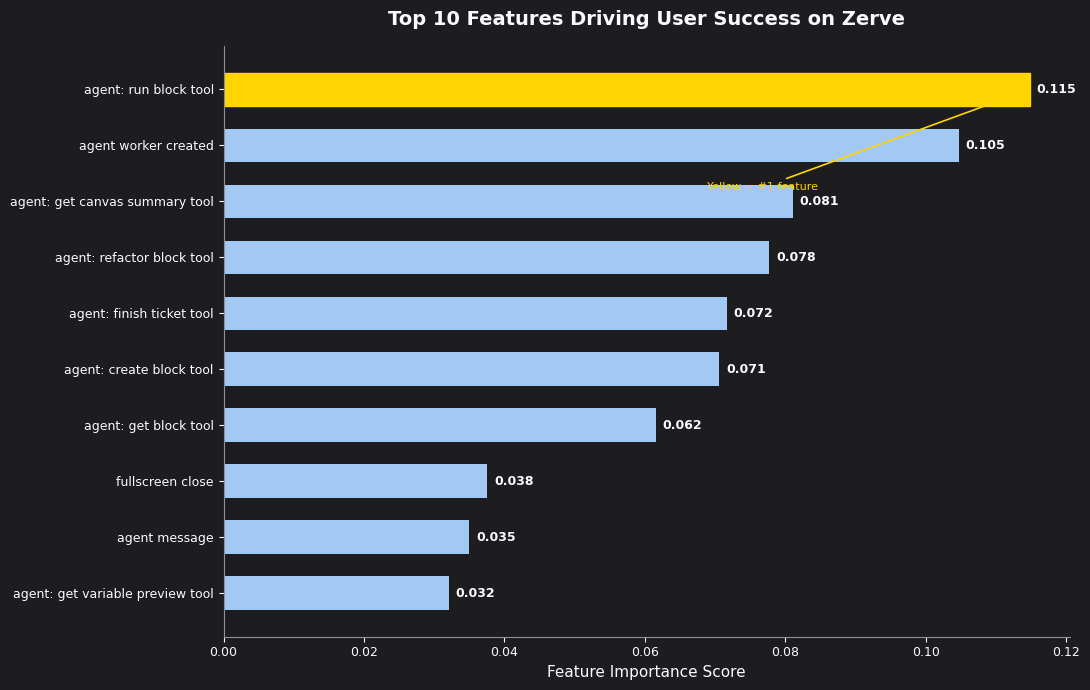

Top 10 feature importances (chart above):
   1. agent_tool_call_run_block_tool: 0.1148
   2. agent_worker_created: 0.1047
   3. agent_tool_call_get_canvas_summary_tool: 0.0811
   4. agent_tool_call_refactor_block_tool: 0.0777
   5. agent_tool_call_finish_ticket_tool: 0.0717
   6. agent_tool_call_create_block_tool: 0.0705
   7. agent_tool_call_get_block_tool: 0.0615
   8. fullscreen_close: 0.0376
   9. agent_message: 0.0350
  10. agent_tool_call_get_variable_preview_tool: 0.0321


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Reconstruct top features directly from model and X to avoid stale index issues
_feat_names = list(X.columns)
_importances = model.feature_importances_
_sorted_idx = sorted(range(len(_importances)), key=lambda i: _importances[i], reverse=True)[:10]

# Build ascending order for horizontal bar chart (bottom = most important)
_plot_names = [_feat_names[i] for i in reversed(_sorted_idx)]
_plot_scores = [_importances[i] for i in reversed(_sorted_idx)]

# Zerve design system colors
_bg_color = '#1D1D20'
_text_color = '#fbfbff'
_bar_color = '#A1C9F4'
_highlight_color = '#ffd400'

fig_importance, ax = plt.subplots(figsize=(11, 7))
fig_importance.patch.set_facecolor(_bg_color)
ax.set_facecolor(_bg_color)

# Plot horizontal bars
_bars = ax.barh(range(len(_plot_names)), _plot_scores, color=_bar_color, edgecolor='none', height=0.6)

# Highlight the top feature (last in ascending order = highest)
_bars[-1].set_color(_highlight_color)

# Add value labels on bars
for _i, (_val, _bar) in enumerate(zip(_plot_scores, _bars)):
    ax.text(_val + 0.001, _i, f'{_val:.3f}', va='center', ha='left',
            color=_text_color, fontsize=9, fontweight='bold')

# Set y-tick labels to feature names (cleaned up)
_clean_names = [n.replace('agent_tool_call_', 'agent: ').replace('_', ' ') for n in _plot_names]
ax.set_yticks(range(len(_plot_names)))
ax.set_yticklabels(_clean_names, color=_text_color, fontsize=9)

# Styling
ax.set_xlabel('Feature Importance Score', color=_text_color, fontsize=11)
ax.set_title('Top 10 Features Driving User Success on Zerve', color=_text_color,
             fontsize=14, fontweight='bold', pad=15)
ax.tick_params(colors=_text_color, labelsize=9)
ax.spines['bottom'].set_color('#909094')
ax.spines['left'].set_color('#909094')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.label.set_color(_text_color)

# Add annotation
ax.annotate('Yellow = #1 feature', xy=(_plot_scores[-1], len(_plot_names)-1),
            xytext=(_plot_scores[-1] * 0.6, len(_plot_names) - 2.8),
            color=_highlight_color, fontsize=8,
            arrowprops=dict(arrowstyle='->', color=_highlight_color, lw=1.2))

plt.tight_layout()
plt.show()

print("Top 10 feature importances (chart above):")
for _i, _idx in enumerate(_sorted_idx, 1):
    print(f"  {_i:2}. {_feat_names[_idx]}: {_importances[_idx]:.4f}")


User Success Distribution (based on P80 activity threshold):
  Successful (1): 73 users (20.1%)
  Non-successful (0): 290 users (79.9%)
  Total users: 363
  Success threshold: >29 events (P80)


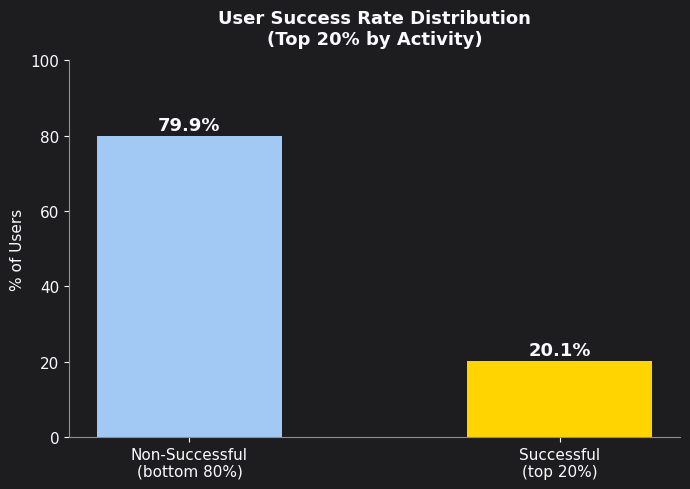

In [ ]:
import matplotlib.pyplot as plt

# Success distribution statistics
_success_counts = user_df['success'].value_counts()
_success_pct = user_df['success'].value_counts(normalize=True) * 100

print("User Success Distribution (based on P80 activity threshold):")
print(f"  Successful (1): {_success_counts[1]:,} users ({_success_pct[1]:.1f}%)")
print(f"  Non-successful (0): {_success_counts[0]:,} users ({_success_pct[0]:.1f}%)")
print(f"  Total users: {len(user_df):,}")
print(f"  Success threshold: >{int(threshold):,} events (P80)")

# Visualization
_bg_color = '#1D1D20'
_text_color = '#fbfbff'

fig_success_dist, ax_dist = plt.subplots(figsize=(7, 5))
fig_success_dist.patch.set_facecolor(_bg_color)
ax_dist.set_facecolor(_bg_color)

_labels = ['Non-Successful\n(bottom 80%)', 'Successful\n(top 20%)']
_values = [_success_pct[0], _success_pct[1]]
_colors = ['#A1C9F4', '#ffd400']

_bars = ax_dist.bar(_labels, _values, color=_colors, edgecolor='none', width=0.5)

# Add value labels on top of bars
for _bar, _val in zip(_bars, _values):
    ax_dist.text(_bar.get_x() + _bar.get_width() / 2, _bar.get_height() + 0.5,
                 f'{_val:.1f}%', ha='center', va='bottom', color=_text_color, fontsize=13, fontweight='bold')

ax_dist.set_ylabel('% of Users', color=_text_color, fontsize=11)
ax_dist.set_title('User Success Rate Distribution\n(Top 20% by Activity)', color=_text_color,
                  fontsize=13, fontweight='bold', pad=12)
ax_dist.set_ylim(0, 100)
ax_dist.tick_params(colors=_text_color, labelsize=11)
ax_dist.spines['bottom'].set_color('#909094')
ax_dist.spines['left'].set_color('#909094')
ax_dist.spines['top'].set_visible(False)
ax_dist.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()
